# 准备数据

In [2]:
import sys
sys.path.append('F:\\git\\vnpy_hub\\vnpy')

In [5]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [7]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [9]:
# 设置任务参数
name = "300_lasso"
index_symbol: str = "000300.SSE"
start: str = "2008-01-01"
end: str = "2023-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [23]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [7]:
# 加载模块
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm,
    process_fill_na
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [8]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [8]:
df

datetime,open,high,low,close,volume,turnover,open_interest,vwap,vt_symbol
datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,str
2007-09-24 00:00:00,0.954962,1.04754,0.929108,1.0,3.4769344e7,8.4223008e8,0.0,24.223352,"""600357.SSE"""
2007-09-25 00:00:00,0.989992,1.042535,0.957048,0.972477,3.0909656e7,7.33287488e8,0.0,23.723572,"""600357.SSE"""
2007-09-26 00:00:00,0.960384,0.972477,0.87573,0.897415,2.5543776e7,5.62652672e8,0.0,22.026995,"""600357.SSE"""
2007-09-27 00:00:00,0.895746,0.940784,0.87573,0.938699,1.5907337e7,3.461064e8,0.0,21.757658,"""600357.SSE"""
2007-09-28 00:00:00,0.942869,0.984153,0.938699,0.941618,2.167795e7,4.96808576e8,0.0,22.917692,"""600357.SSE"""
…,…,…,…,…,…,…,…,…,…
2024-01-04 00:00:00,0.340059,0.340059,0.333447,0.33628,1.15104e7,4.0958676e7,0.0,3.558406,"""000402.SZSE"""
2024-01-05 00:00:00,0.33628,0.342893,0.334391,0.337225,2.0449118e7,7.3394208e7,0.0,3.589114,"""000402.SZSE"""
2024-01-08 00:00:00,0.33817,0.339114,0.326834,0.327779,1.79017e7,6.2911928e7,0.0,3.514299,"""000402.SZSE"""


In [9]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period = ("2008-01-01", "2014-12-31"),
    valid_period = ("2015-01-01", "2016-12-31"),
    test_period = ("2017-01-01", "2020-8-31"),
)

In [10]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

dataset.add_processor("infer", partial(process_fill_na, fill_value=0))

In [11]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [12]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=3)

2025-08-17 21:09:23 开始计算表达式因子特征


100%|██████████| 159/159 [48:58<00:00, 18.48s/it]  

2025-08-17 21:58:22 开始合并结果数据因子特征



0it [00:00, ?it/s]


2025-08-17 21:58:22 开始筛选成分股数据


100%|██████████| 819/819 [00:10<00:00, 78.57it/s] 


Dropped 7.9% entries from factor data: 0.4% in forward returns computation and 7.6% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,0.783112,0.093004,0.131694,184875,10.066758
2.0,0.001415,0.849006,0.241332,0.181790,183643,9.999673
3.0,0.010818,0.886883,0.321613,0.204949,183042,9.966948
4.0,0.016097,0.914460,0.388197,0.216491,183571,9.995753
5.0,0.027027,0.936720,0.450874,0.221048,183885,10.012851
6.0,0.047662,0.954670,0.514338,0.219331,182817,9.954696
7.0,0.071903,0.967680,0.582028,0.210957,183264,9.979036
8.0,0.101998,0.980325,0.659240,0.193268,183326,9.982412
9.0,0.148624,0.998511,0.752302,0.162727,183361,9.984318


Returns Analysis


,1D,5D,10D
Ann. alpha,0.100,-0.035,-0.002
beta,0.024,0.025,0.032
Mean Period Wise Return Top Quantile (bps),15.172,1.996,3.591
Mean Period Wise Return Bottom Quantile (bps),-4.951,0.334,1.360
Mean Period Wise Spread (bps),20.123,1.677,2.406


<Figure size 640x480 with 0 Axes>

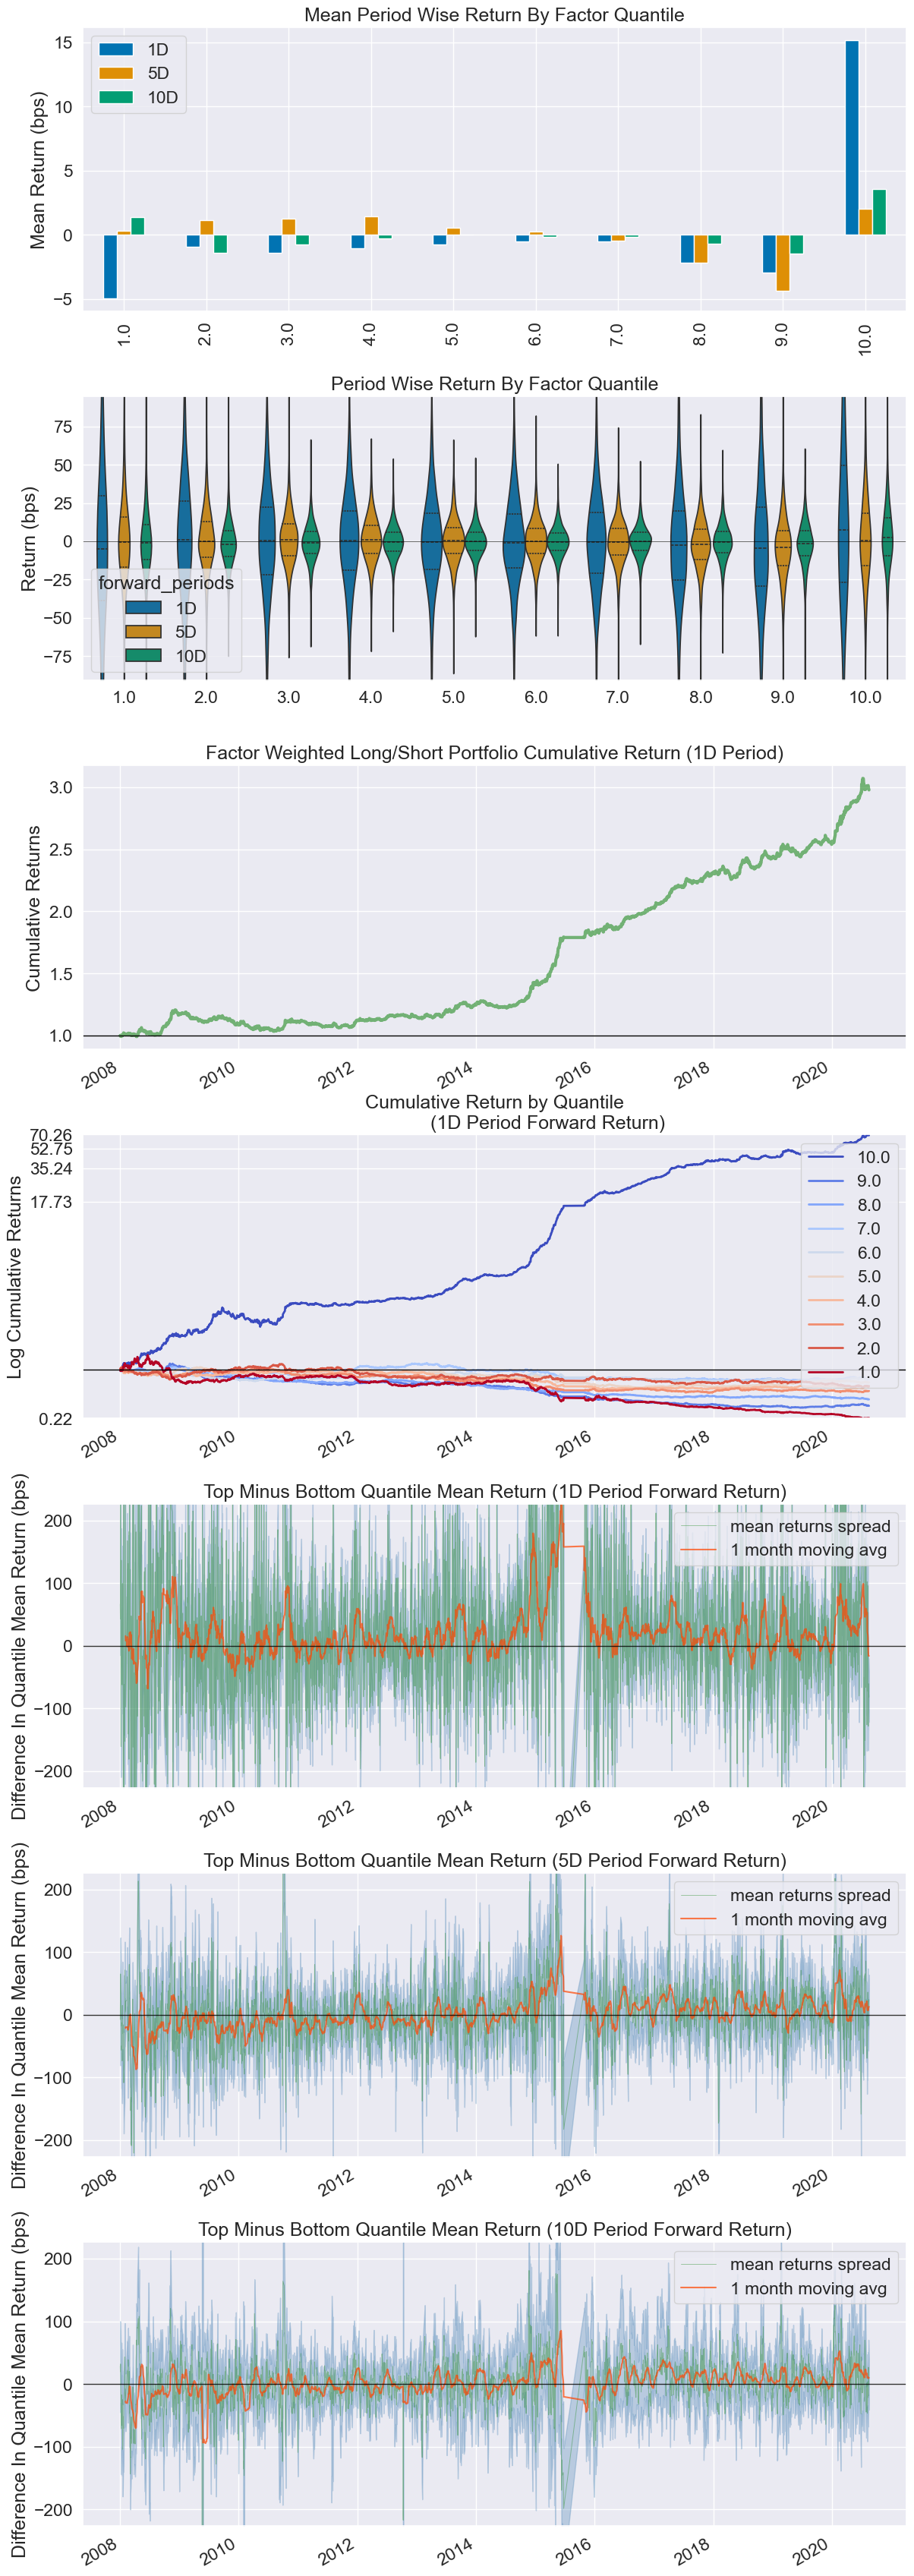

Information Analysis


,1D,5D,10D
IC Mean,-0.029,-0.031,-0.005
IC Std.,0.137,0.129,0.128
Risk-Adjusted IC,-0.209,-0.238,-0.038
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


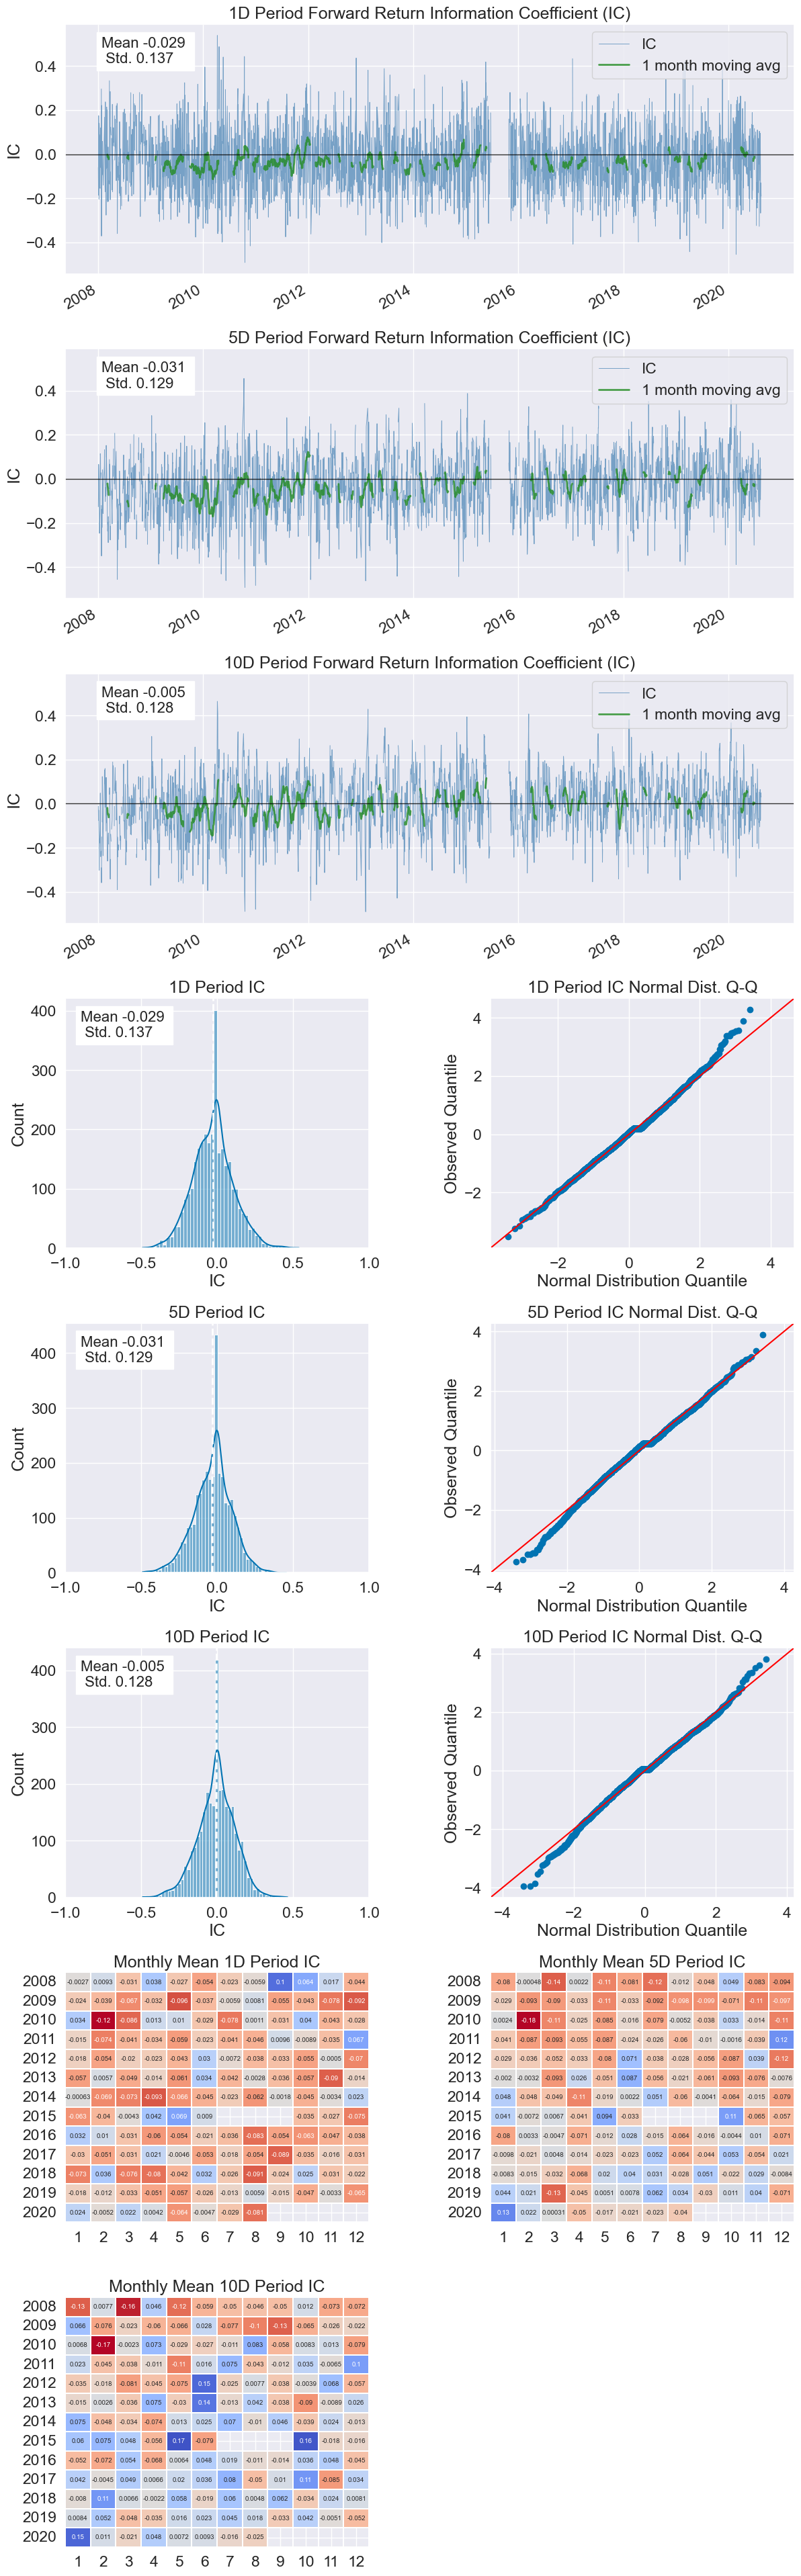

C:\Users\Windows 10\AppData\Roaming\Python\Python310\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.470,0.661,0.674
Quantile 2.0 Mean Turnover,0.752,0.906,0.892
Quantile 3.0 Mean Turnover,0.818,0.899,0.894
Quantile 4.0 Mean Turnover,0.845,0.894,0.893
Quantile 5.0 Mean Turnover,0.856,0.891,0.894
Quantile 6.0 Mean Turnover,0.860,0.896,0.895
Quantile 7.0 Mean Turnover,0.853,0.897,0.898
Quantile 8.0 Mean Turnover,0.835,0.899,0.896
Quantile 9.0 Mean Turnover,0.794,0.901,0.892
Quantile 10.0 Mean Turnover,0.673,0.893,0.885


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.605,0.038,0.083


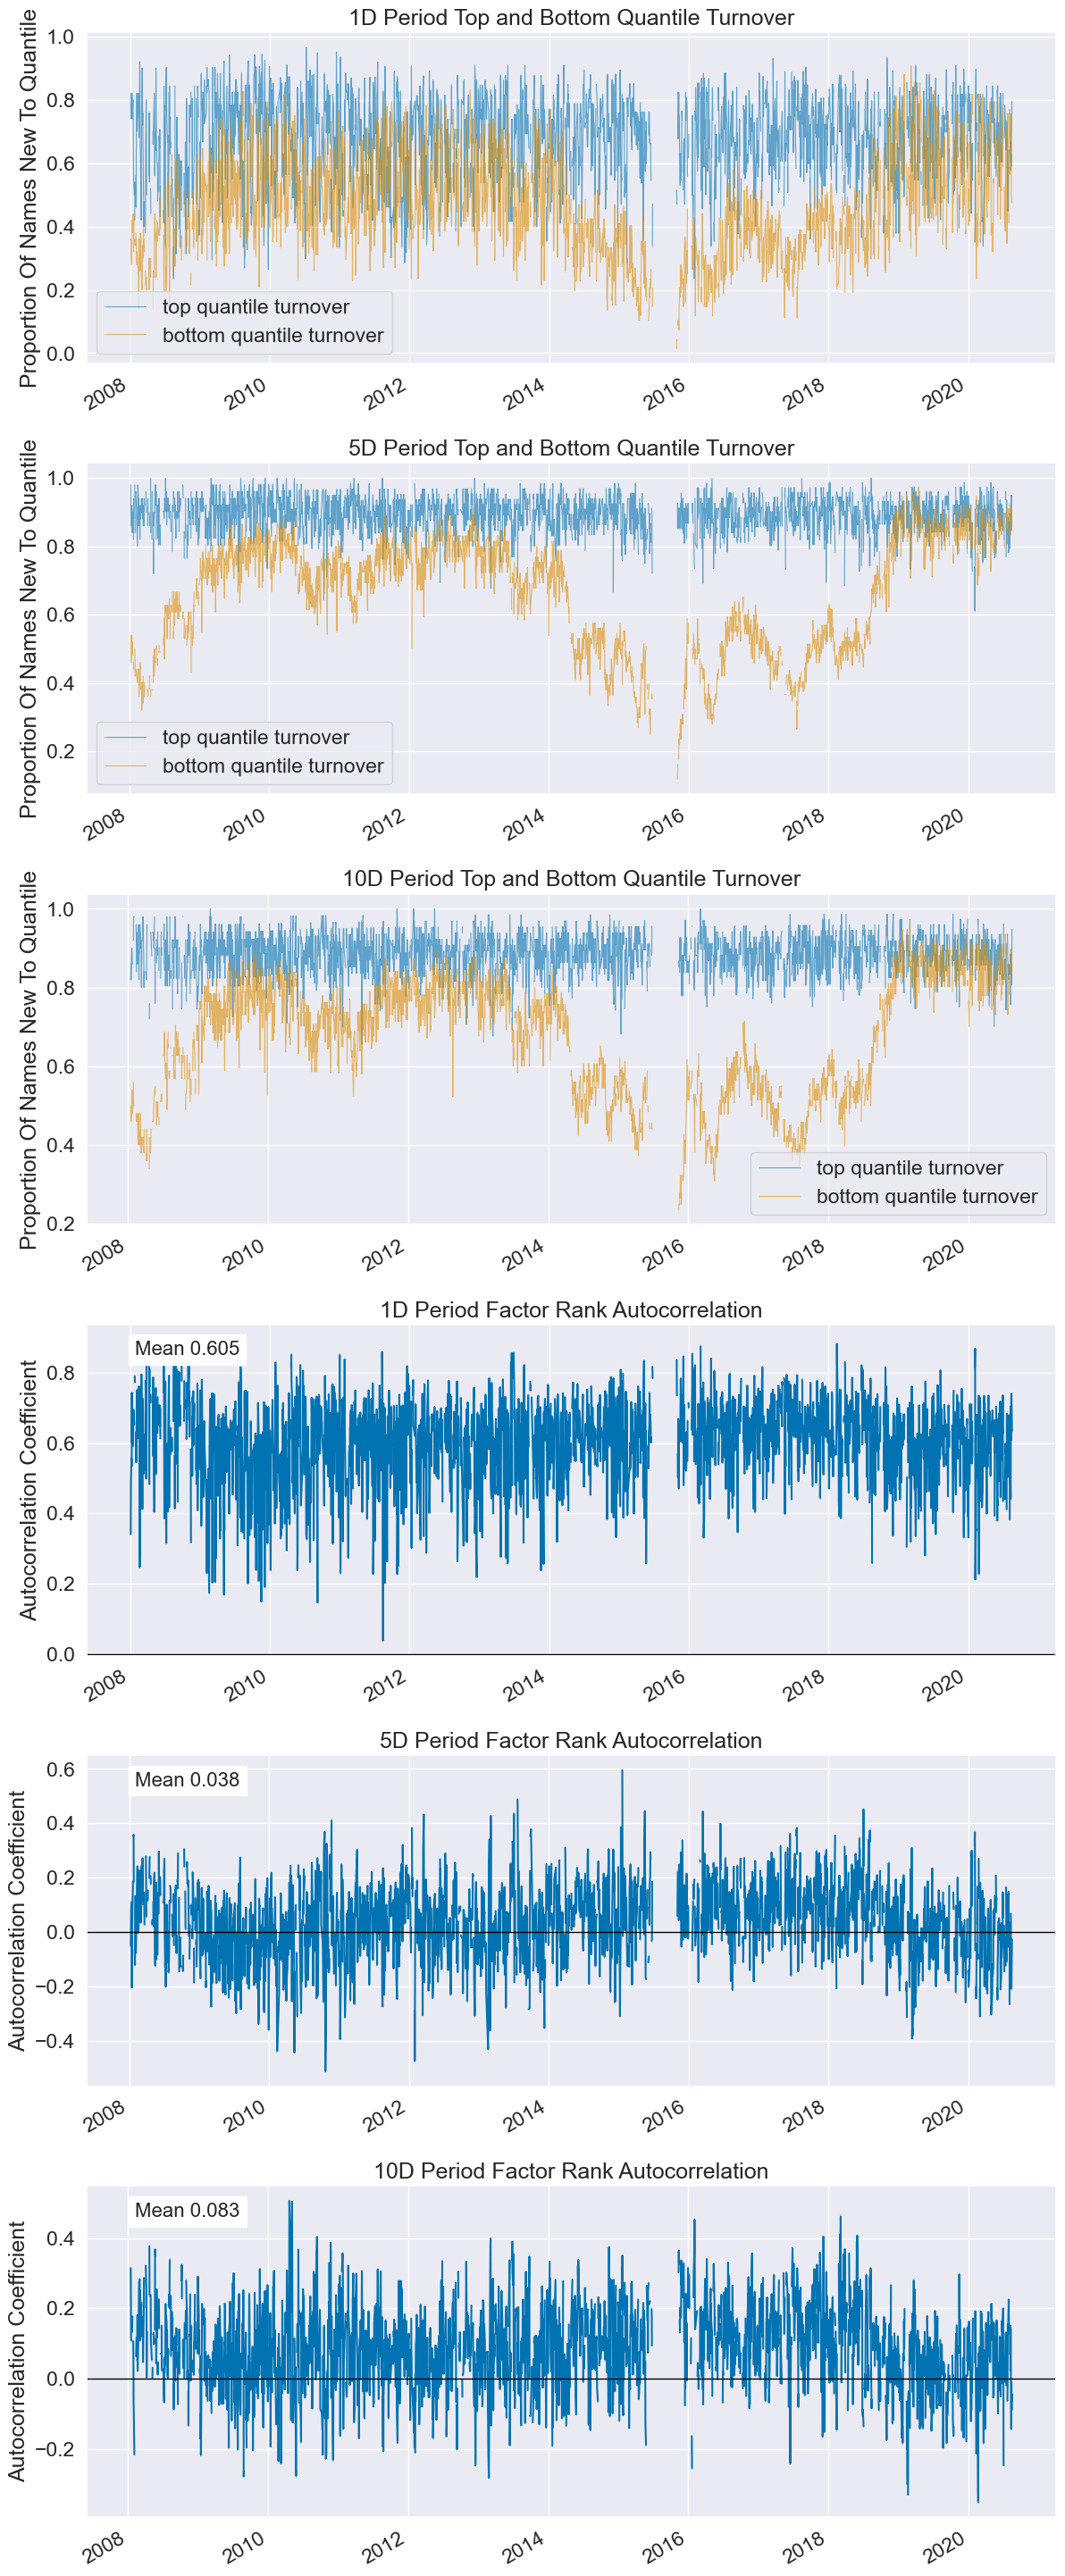

In [13]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

In [14]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [3]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lasso_model import LassoModel

In [10]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [11]:
# 创建模型对象
model: AlphaModel = LassoModel()

In [12]:
# 使用数据集训练模型
model.fit(dataset)

C:\Users\Windows 10\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.266e+05, tolerance: 6.548e+01
  model = cd_fast.enet_coordinate_descent(


In [13]:
# 查看模型细节
model.detail()

2025-08-17 22:22:47 LASSO模型特征总数量: 35
2025-08-17 22:22:47 roc_30: 0.191338
2025-08-17 22:22:47 ma_5: -0.120610
2025-08-17 22:22:47 rsv_30: 0.084195
2025-08-17 22:22:47 rank_10: -0.073321
2025-08-17 22:22:47 klow_2: -0.069128
2025-08-17 22:22:47 rank_5: -0.043522
2025-08-17 22:22:47 rsv_20: 0.041595
2025-08-17 22:22:47 qtld_5: -0.038386
2025-08-17 22:22:47 rank_60: 0.037178
2025-08-17 22:22:47 max_60: 0.035866
2025-08-17 22:22:47 imxd_5: -0.035657
2025-08-17 22:22:47 imax_30: -0.027970
2025-08-17 22:22:47 rsqr_5: -0.027038
2025-08-17 22:22:47 rsqr_10: -0.021743
2025-08-17 22:22:47 sumd_30: 0.020589
2025-08-17 22:22:47 ksft_2: -0.016968
2025-08-17 22:22:47 rsv_10: 0.016561
2025-08-17 22:22:47 wvma_30: -0.013480
2025-08-17 22:22:47 rsqr_30: -0.011664
2025-08-17 22:22:47 wvma_60: -0.010945
2025-08-17 22:22:47 imin_10: 0.010000
2025-08-17 22:22:47 imxd_60: 0.008393
2025-08-17 22:22:47 wvma_20: -0.007713
2025-08-17 22:22:47 sumd_60: 0.007140
2025-08-17 22:22:47 imin_5: 0.006505
2025-08-17 22:

In [14]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [15]:
model: AlphaModel = lab.load_model(name)

In [16]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.1% entries from factor data: 1.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.719767,0.014200,-0.076175,0.028264,26460,10.000000
2,-0.124209,0.036205,-0.047443,0.022947,26461,10.000378
3,-0.105156,0.045591,-0.032592,0.023157,26462,10.000756
4,-0.092367,0.052980,-0.020943,0.023427,26458,9.999244
5,-0.081177,0.060880,-0.010491,0.023479,26466,10.002268
6,-0.073268,0.071211,-0.000398,0.023447,26467,10.002646
7,-0.064765,0.082490,0.010050,0.023161,26473,10.004913
8,-0.053279,0.091156,0.021500,0.022659,26483,10.008692
9,-0.042854,0.104719,0.035873,0.022207,26432,9.989418


Returns Analysis


,1D,5D,10D
Ann. alpha,0.172,0.128,0.071
beta,0.041,0.047,0.036
Mean Period Wise Return Top Quantile (bps),9.130,8.002,5.505
Mean Period Wise Return Bottom Quantile (bps),-12.846,-7.675,-3.986
Mean Period Wise Spread (bps),21.976,15.673,9.497


<Figure size 640x480 with 0 Axes>

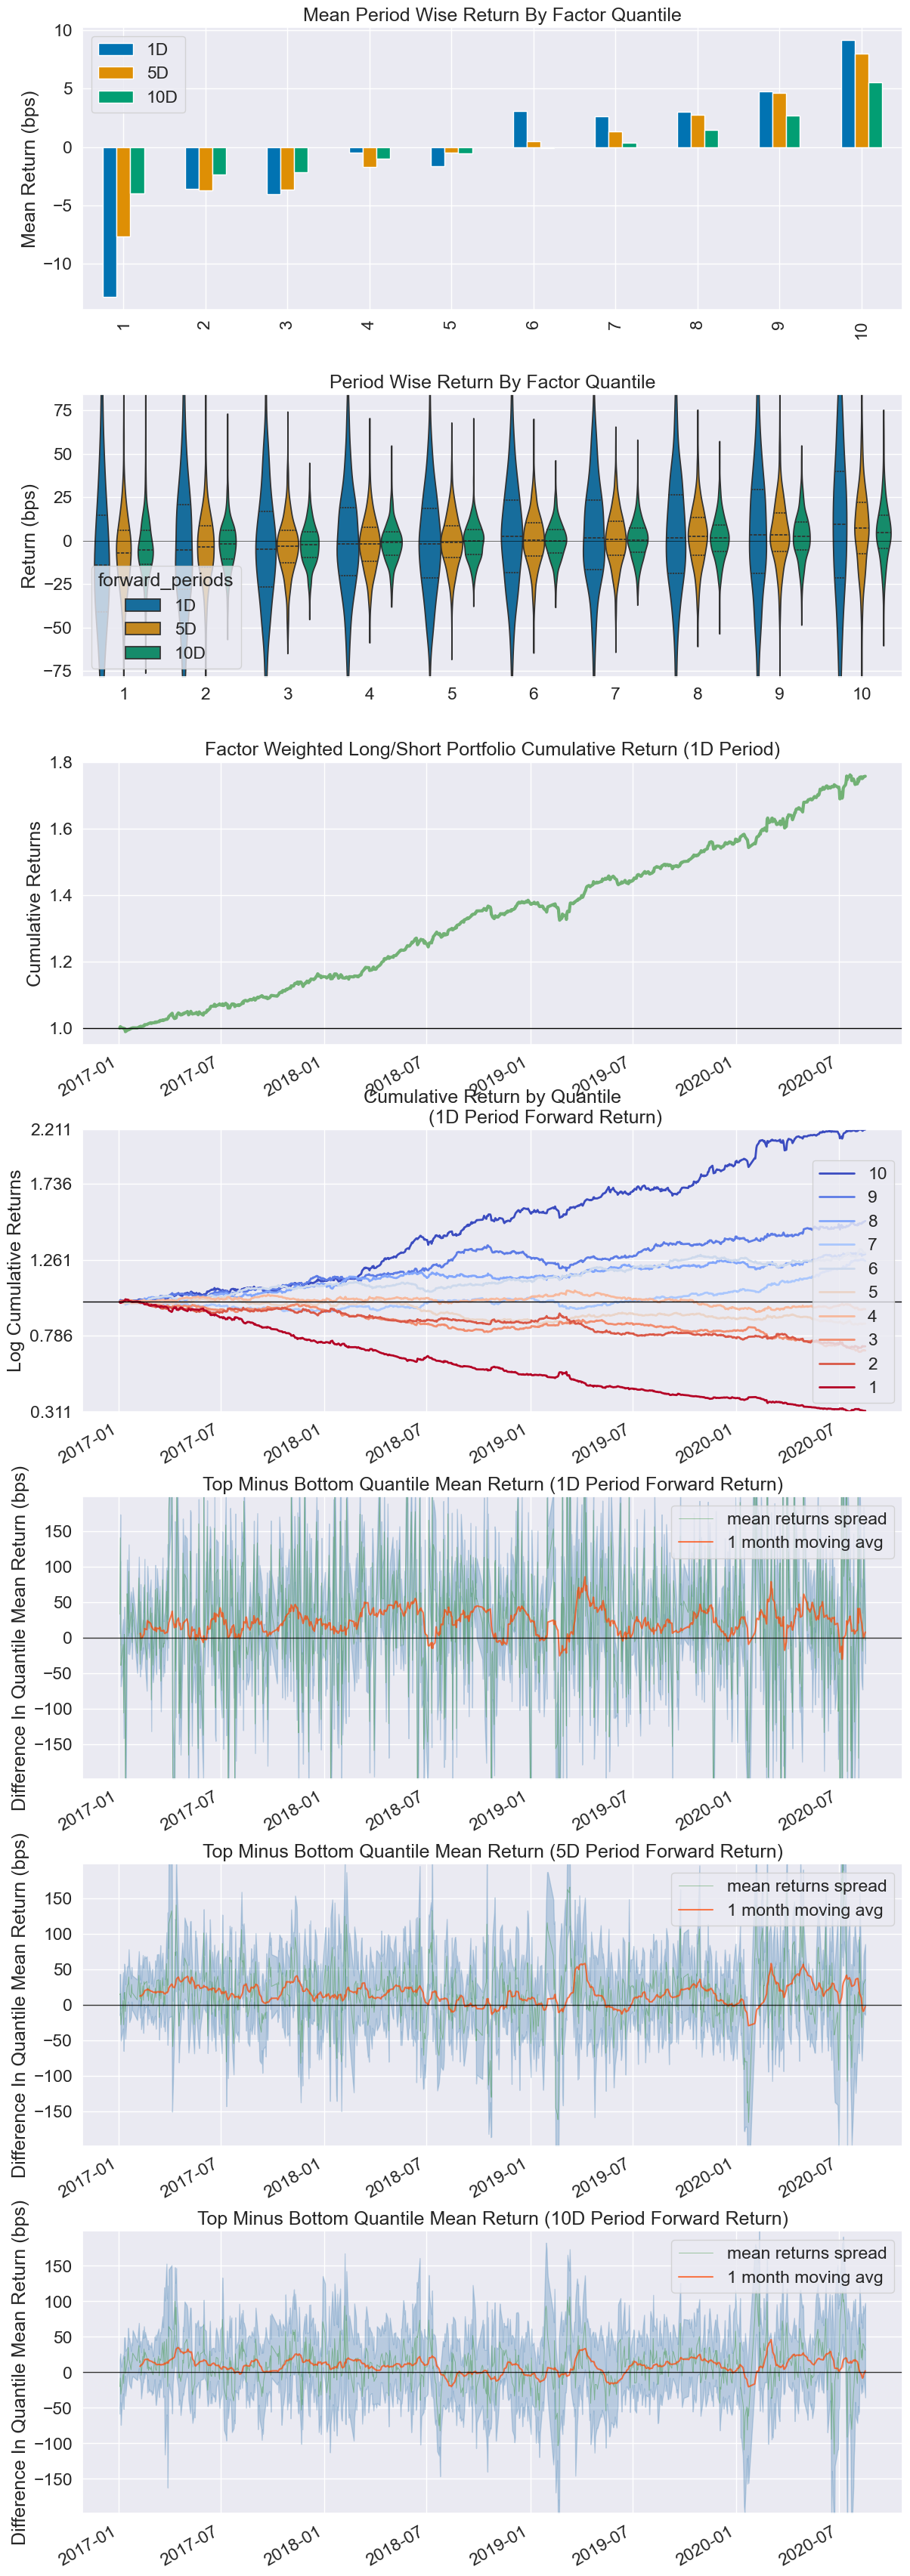

Information Analysis


,1D,5D,10D
IC Mean,0.048,0.052,0.044
IC Std.,0.136,0.135,0.130
Risk-Adjusted IC,0.354,0.389,0.338
t-stat(IC),10.500,11.545,10.046
p-value(IC),0.000,0.000,0.000
IC Skew,0.036,0.157,0.119
IC Kurtosis,0.203,0.406,0.528


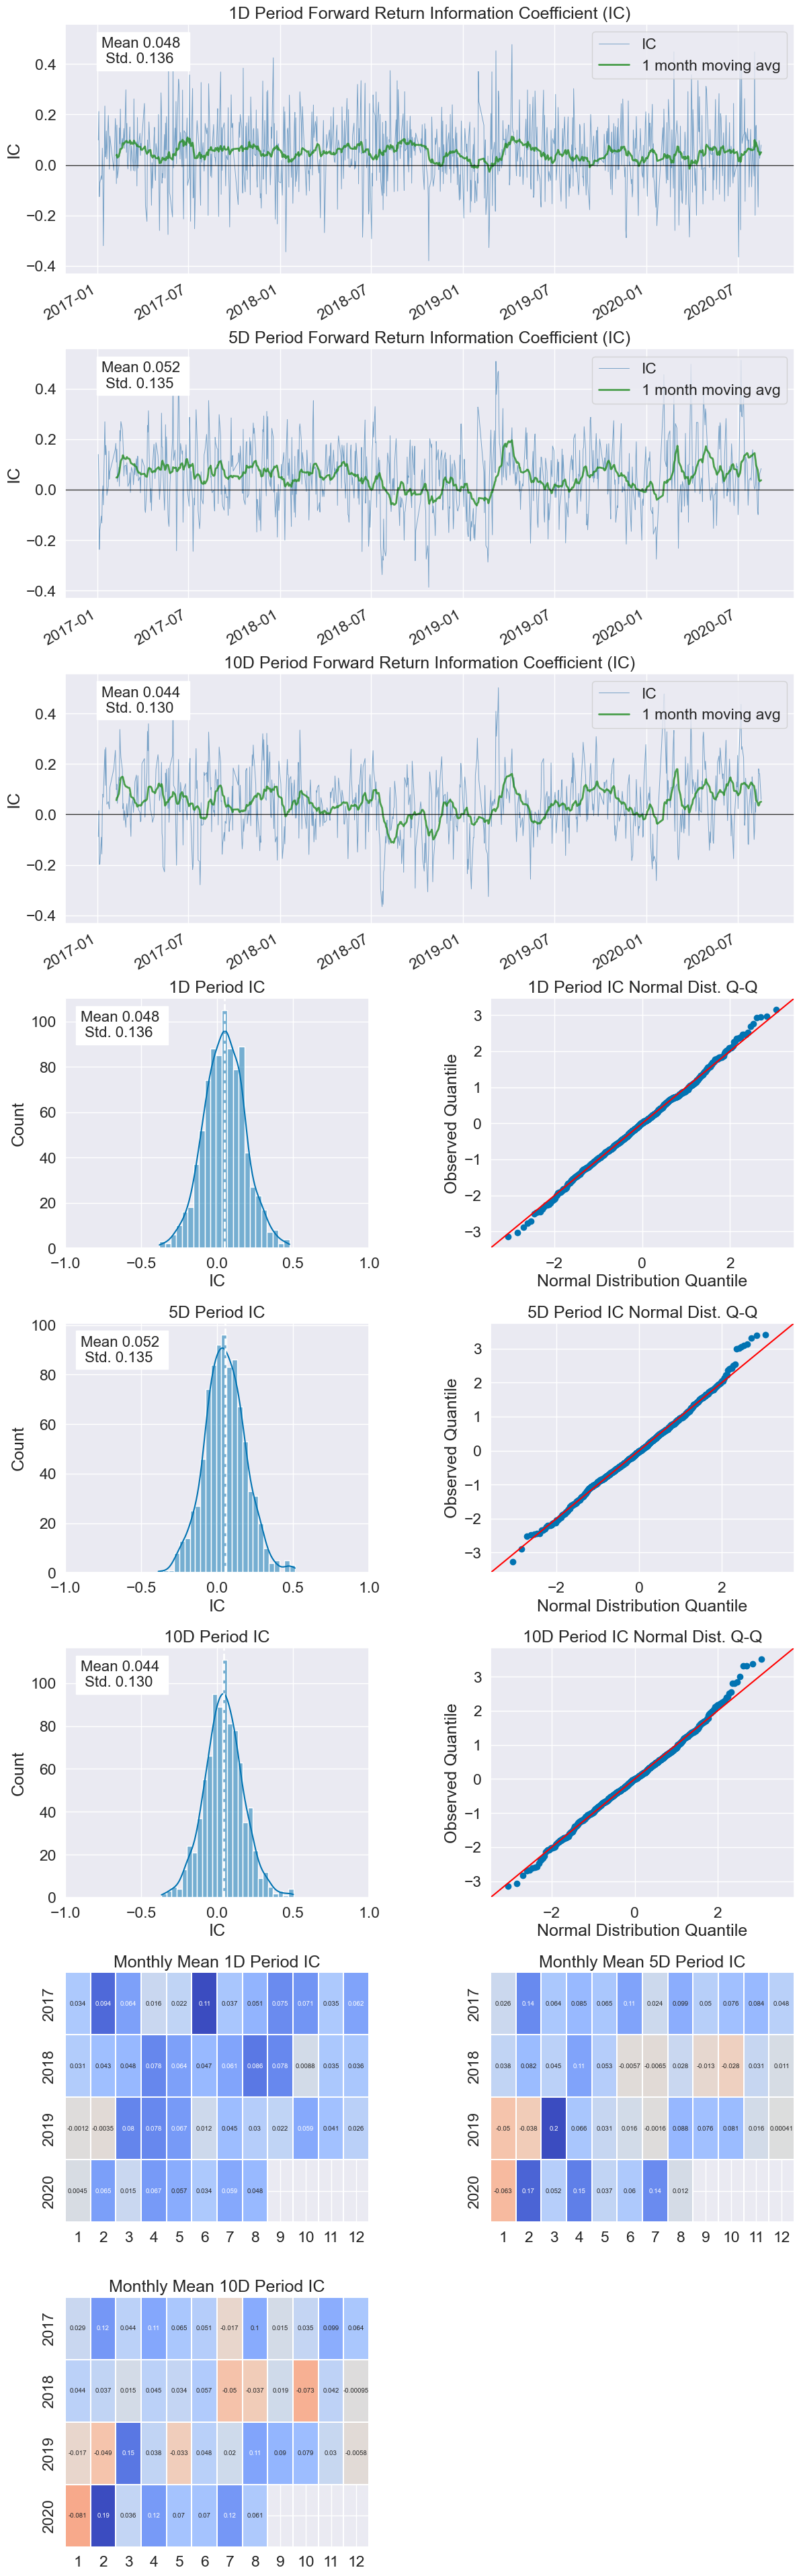

C:\Users\Windows 10\AppData\Roaming\Python\Python310\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.586,0.818,0.846
Quantile 2 Mean Turnover,0.798,0.885,0.893
Quantile 3 Mean Turnover,0.845,0.895,0.897
Quantile 4 Mean Turnover,0.857,0.899,0.897
Quantile 5 Mean Turnover,0.867,0.897,0.899
Quantile 6 Mean Turnover,0.866,0.899,0.900
Quantile 7 Mean Turnover,0.860,0.896,0.895
Quantile 8 Mean Turnover,0.834,0.888,0.894
Quantile 9 Mean Turnover,0.793,0.881,0.883
Quantile 10 Mean Turnover,0.590,0.827,0.851


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.591,0.167,0.109


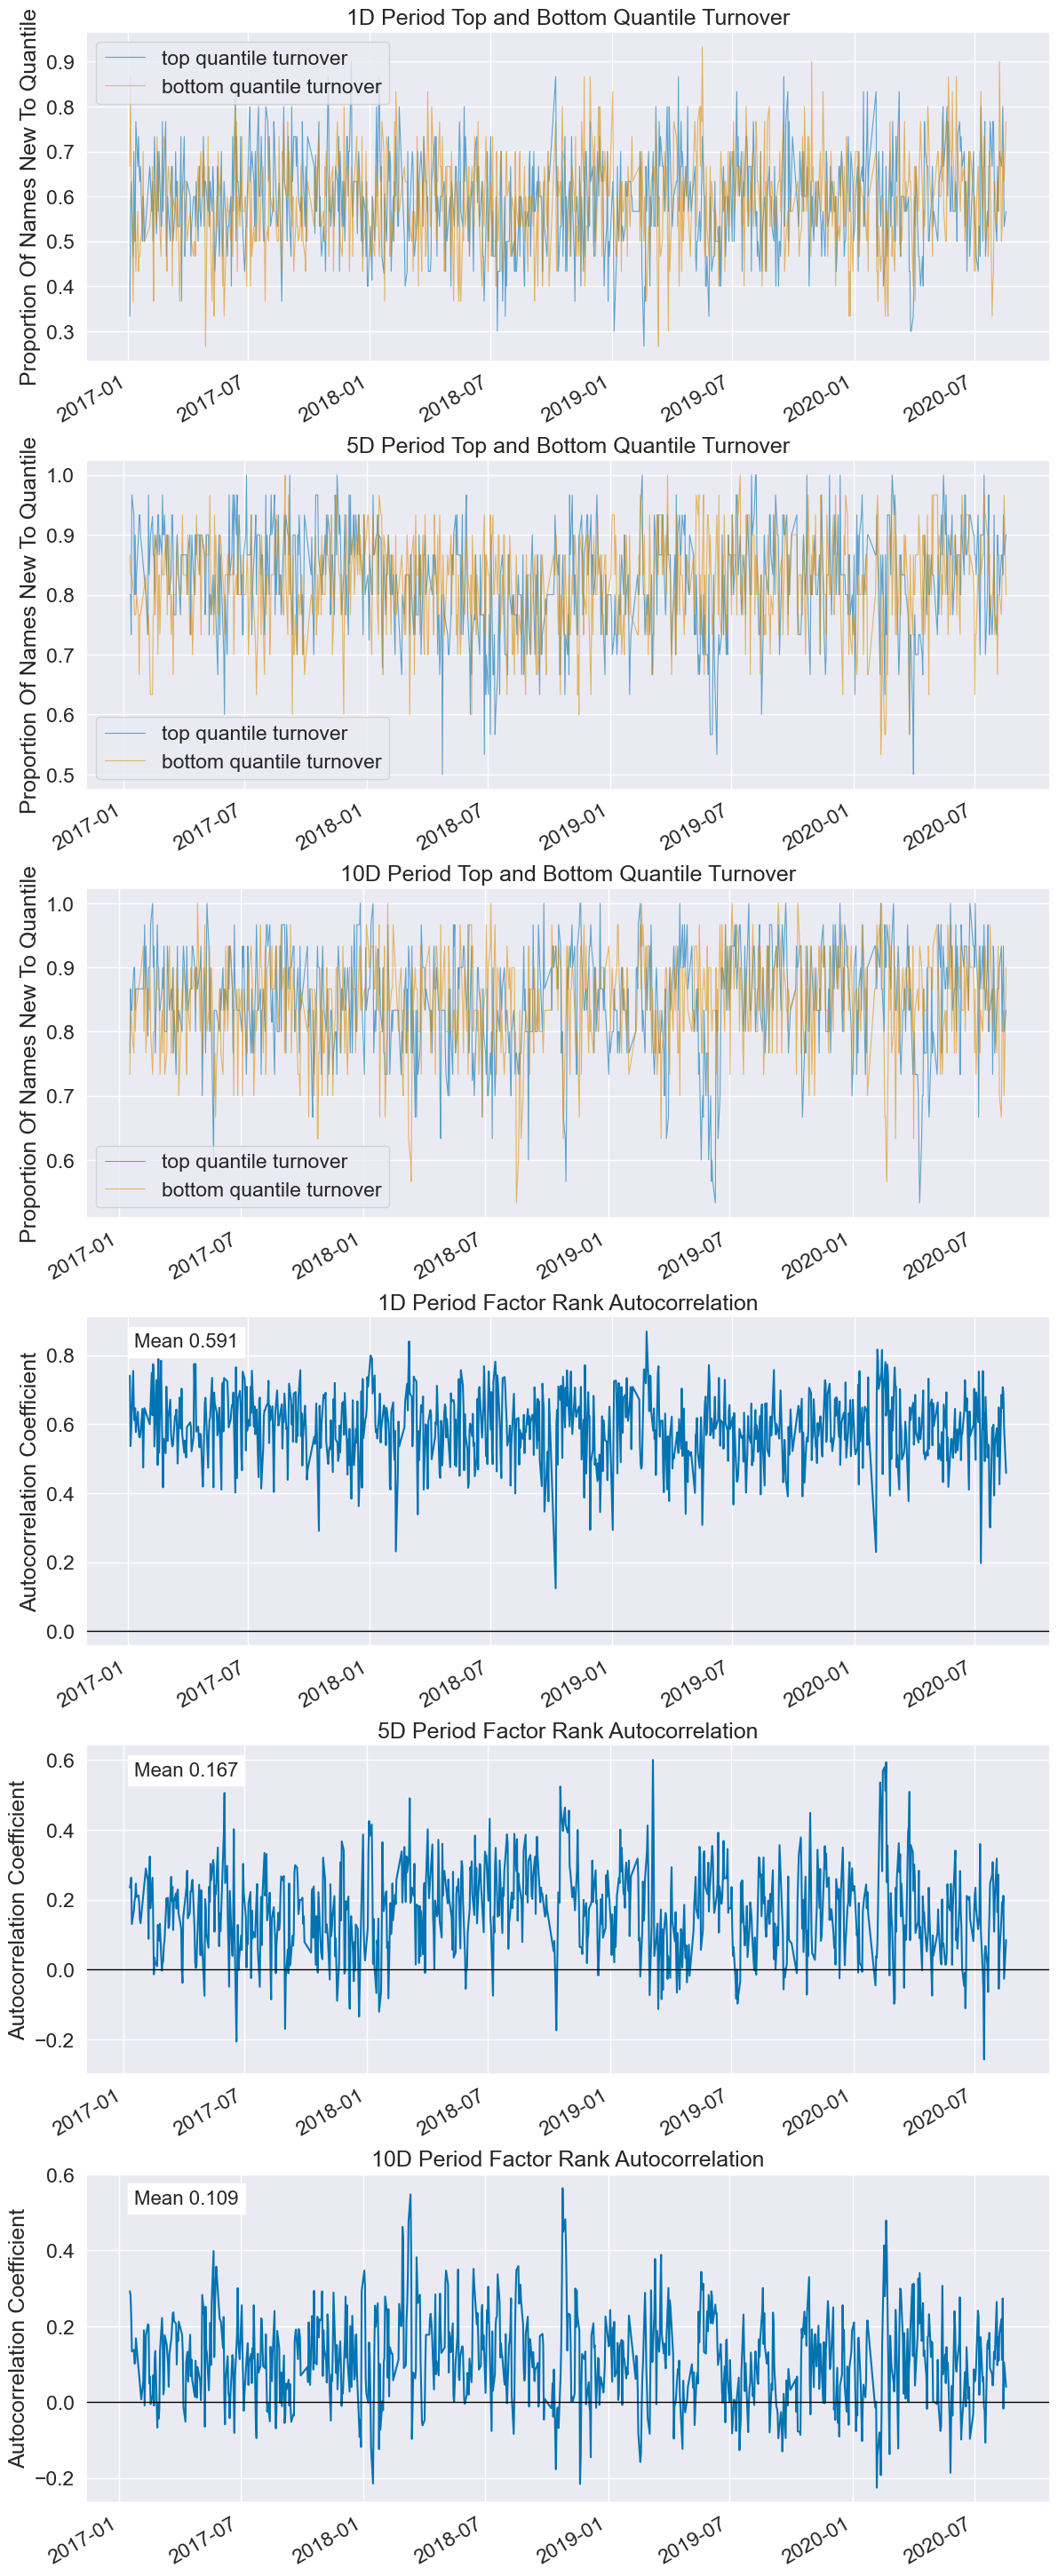

In [17]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [18]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [2]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

ModuleNotFoundError: No module named 'vnpy'

In [20]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [21]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [ ]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2017, 1, 1),
    end=datetime(2020, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [25]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2025-08-17 22:24:20 开始加载历史数据


100%|██████████| 819/819 [00:05<00:00, 149.69it/s]

2025-08-17 22:24:25 部分合约历史数据为空：['605499.SSE', '600941.SSE', '600905.SSE', '688041.SSE', '688271.SSE', '000024.SZSE', '300999.SZSE', '601825.SSE', '600938.SSE', '300957.SZSE', '601268.SSE', '300866.SZSE', '688065.SSE', '300896.SZSE', '601059.SSE', '300919.SZSE', '688223.SSE', '600786.SSE', '000527.SZSE', '001289.SZSE', '601868.SSE', '600102.SSE', '688187.SSE', '000562.SZSE', '301269.SZSE', '600631.SSE', '300888.SZSE', '600357.SSE', '600001.SSE', '601995.SSE', '605117.SSE', '600087.SSE', '688303.SSE', '600591.SSE', '601299.SSE', '600832.SSE', '300979.SZSE', '601728.SSE']
2025-08-17 22:24:25 所有历史数据加载完成
2025-08-17 22:24:25 策略初始化完成
2025-08-17 22:24:25 开始回放历史数据


2025-08-17 22:24:30 历史数据回放结束
2025-08-17 22:24:30 开始计算逐日盯市盈亏
2025-08-17 22:24:31 逐日盯市盈亏计算完成
2025-08-17 22:24:31 开始计算策略统计指标
2025-08-17 22:24:31 ------------------------------
2025-08-17 22:24:31 首个交易日：  2017-01-03
2025-08-17 22:24:31 最后交易日：  2020-07-31
2025-08-17 22:24:31 总交易日：  871
2025-08-17 22:24:31 盈利交易日：  482
2025-08-17 22:24:31 亏损交易日：  388
2025-08-17 22:24:31 起始资金：  100,000,000.00
2025-08-17 22:24:31 结束资金：  218,451,196.06
2025-08-17 22:24:31 总收益率：  118.45%
2025-08-17 22:24:31 年化收益：  32.64%
2025-08-17 22:24:31 最大回撤:   -40,244,930.01
2025-08-17 22:24:31 百分比最大回撤: -28.05%
2025-08-17 22:24:31 最长回撤天数:   219
2025-08-17 22:24:31 总盈亏：  118,451,196.06
2025-08-17 22:24:31 总手续费：  16,047,779.84
2025-08-17 22:24:31 总成交金额：  21,424,621,860.13
2025-08-17 22:24:31 总成交笔数：  4969
2025-08-17 22:24:31 日均盈亏：  135,994.48
2025-08-17 22:24:31 日均手续费：  18,424.55
2025-08-17 22:24:31 日均成交金额：  24,597,728.89
2025-08-17 22:24:31 日均成交笔数：  5.704936854190586
2025-08-17 22:24:31 日均收益率：  0.10%
2025-08-17 22:24:31 收益标准差：

In [26]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)